# Note

**net_impact** -> **bulk_deformation**

**We_Re** -> **K**

# Prerequisites

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('darkgrid')
plt.rcParams['figure.dpi'] = 300

## Main df

### **net_impact** to **bulk_deformation**
### **We_Re** -> **K**

In [2]:
# Import data
df_main = pd.read_excel('../data/df_main.xlsx')

# **net_impact** to **bulk_deformation**
df_main = df_main.rename(
    {
        'net_impact': 'bulk_deformation',
        'We_Re': "K"
    },
    axis=1
)

display(df_main.head())
df_main.info()

,test,bulk_deformation,splashing,splashing_spectrum,breaking_up,rebound,one_drop,voltage,long_impulse_duration,long_impulse_dur_binary,...,inclination,roughness_binary,particle_liquid_density_ratio,volume_fraction_binary,particle_diameter_cat,particle_droplet_diameter_ratio,velocity,Re,We,K
0,3,0,1,2,0,0,1,105.0,10,low,...,0,0,1.219512,1,small,0.013301,3.961141,1492.516020,1492.302356,240.108847
1,4,0,1,2,0,0,1,105.0,10,low,...,0,0,1.219512,1,small,0.013301,3.961141,1492.516020,1492.302356,240.108847
2,5,0,1,2,0,0,1,105.0,10,low,...,0,0,1.219512,1,small,0.013301,3.961141,1492.516020,1492.302356,240.108847
3,7,0,1,2,0,0,0,105.0,10,low,...,0,0,1.219512,1,small,0.013833,3.961141,1435.111557,1434.906112,233.148786
4,8,0,1,2,0,0,0,105.0,10,low,...,0,0,1.219512,1,small,0.013833,3.961141,1435.111557,1434.906112,233.148786


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   bulk_deformation                 372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   splashing_spectrum               372 non-null    int64  
 4   breaking_up                      372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   one_drop                         372 non-null    int64  
 7   voltage                          372 non-null    float64
 8   long_impulse_duration            372 non-null    int64  
 9   long_impulse_dur_binary          372 non-null    object 
 10  wettability                      372 non-null    object 
 11  roughness                        372 non-null    float64
 12  liquid_density        

### Wettability to ordinal

Change wettability to ordinal feature

In [3]:
print('Wettability before encoding')
print(df_main['wettability'].value_counts())
print()

wettability_dict = {
    'lyophilic': 0,
    'neutral': 1,
    'lyophobic': 2,
}

print('Wettability after encoding')
df_main['wettability_ordinal'] = df_main['wettability'].map(wettability_dict)
print(df_main['wettability_ordinal'].value_counts())

Wettability before encoding
wettability
lyophilic    147
neutral      114
lyophobic    111
Name: count, dtype: int64

Wettability after encoding
wettability_ordinal
0    147
1    114
2    111
Name: count, dtype: int64


In [4]:
# GET LATEX
df_tex = (
    pd.DataFrame(df_main[['wettability', 'wettability_ordinal']]
    .value_counts())
    .reset_index()
)
df_tex = df_tex.rename(
    {
        'wettability': 'substrate wettability',
        'wettability_ordinal': 'wettability'
    },
    axis=1
)
display(df_tex)

latex_code = df_tex.to_latex(
    index=False,
    column_format='|l|c|c|',
)

latex_code = latex_code.replace("\\\n", "\\ \hline\n")
print(
    latex_code
)

,substrate wettability,wettability,count
0,lyophilic,0,147
1,neutral,1,114
2,lyophobic,2,111


\begin{tabular}{|l|c|c|}
\toprule
substrate wettability & wettability & count \\ \hline
\midrule
lyophilic & 0 & 147 \\ \hline
neutral & 1 & 114 \\ \hline
lyophobic & 2 & 111 \\ \hline
\bottomrule
\end{tabular}



Drop unnecessary column

In [5]:
df_main['wettability'] = df_main['wettability_ordinal']
df_main = df_main.drop(
    'wettability_ordinal',
    axis=1
)
df_main.info()
print(df_main['wettability'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 30 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   test                             372 non-null    int64  
 1   bulk_deformation                 372 non-null    int64  
 2   splashing                        372 non-null    int64  
 3   splashing_spectrum               372 non-null    int64  
 4   breaking_up                      372 non-null    int64  
 5   rebound                          372 non-null    int64  
 6   one_drop                         372 non-null    int64  
 7   voltage                          372 non-null    float64
 8   long_impulse_duration            372 non-null    int64  
 9   long_impulse_dur_binary          372 non-null    object 
 10  wettability                      372 non-null    int64  
 11  roughness                        372 non-null    float64
 12  liquid_density        

### Labels description:

- **splashing_spectrum**: 
    - **0 - no splashing**, when *'Number of detached small droplets during Spreading' == 0*
    - **1 - semi splashing**, when **gear** occurs, or when few droplets detach
    - **2 - splashing**. Pure splashing, when **many** droplets or **many small** droplets detach
    
- **splashing**: 1 - when *'Number of detached small droplets during Spreading' != 0*;
- **breaking_up**: when *'Number of detached small droplets during Receding or Rim merging' > 0*
- **rebound** consists of next cases:
    - **2 - true rebound**, when droplets detaching during partial rebound, or when droplet rebounds totally.
    
    *True rebound: 'Rebound' == 2 OR ('Rebound' == 1 AND 'Number of detached droplets during Rebound' > 0)*
    - **1 - jet ejection**, when true rebound does not appear.

    *'Rim merging or Central jet ejecting' == 2 AND NOT True rebound*    
    - **0** - no true rebound and no jet ejection. *Other cases*

-  **bulk_deformation** (ex. **net_impact**): when there is 
    - **no Splashing** (no small droplets detached during spreading, *'Number of detached small droplets during Spreading'==0*), 
    - **no Breaking up** (when *'Number of detached small droplets during Receding or Rim merging' == 0*)
    - **no True Rebound** (see True rebound definition early)

### Physical properties

$velocity = \sqrt{2g\cdot height}$

$Re=\frac{velocity \cdot droplet\_diameter \cdot liquid\_density}{viscosity}$

$We=\frac{velocity^2 \cdot droplet\_diameter \cdot liquid\_density}{surface\_tension}$

$K = We^{1/2}Re^{1/4}$

ex. $We\_Re$

particle_droplet_diameter_ratio = particle_mean_diameter / droplet_diameter

particle_liquid_density_ratio = particle_density / liquid_density

*Params above were checked*

Droplet diameter

In [6]:
df_diam = pd.DataFrame(df_main['particle_mean_diameter'].value_counts()).reset_index()
df_diam['particle_mean_diameter'] *= 1e6
df_diam

,particle_mean_diameter,count
0,41.5,279
1,275.0,54
2,137.5,39


Volume fraction

In [7]:
def get_volume_fraction_type(value):
    if value == 1:
        return '8..10 %'
    else:
        return '4..5 %'

df_main['particle_volume_fraction'] = df_main['volume_fraction_binary'].apply(get_volume_fraction_type)
df_main['particle_volume_fraction'].value_counts()

particle_volume_fraction
8..10 %    271
4..5 %     101
Name: count, dtype: int64

In [8]:
# GET LATEX
df_tex = (
    pd.DataFrame(df_main[['particle_volume_fraction', 'volume_fraction_binary']]
    .value_counts(ascending=True))
    .reset_index()
)
# df_tex = df_tex.rename(
#     {
#         'wettability': 'substrate wettability',
#         'wettability_ordinal': 'wettability'
#     },
#     axis=1
# )
# display(df_tex)

latex_code = df_tex.to_latex(
    index=False,
    column_format='|l|c|c|',
)

latex_code = latex_code.replace("\\\n", "\\ \hline\n")
print(
    latex_code
)

\begin{tabular}{|l|c|c|}
\toprule
particle_volume_fraction & volume_fraction_binary & count \\ \hline
\midrule
4..5 % & 0 & 101 \\ \hline
8..10 % & 1 & 271 \\ \hline
\bottomrule
\end{tabular}



In [9]:
df_volume_frac = pd.DataFrame(df_main['volume_fraction_binary'].value_counts()).reset_index()
df_volume_frac

,volume_fraction_binary,count
0,1,271
1,0,101


Return back:

### Main column groups 
(see edit_labels.ipynb)

In [10]:
# targets = ['net_impact', 'splashing']
targets = ['bulk_deformation', 'splashing']
impact_labels = ['splashing_spectrum', 'breaking_up', 'rebound']

# Unnecesary to model
generation_features = [
    'one_drop', 'voltage', 'long_impulse_duration', 'long_impulse_dur_binary'
]

# do not forget 'test'
features_original = [
    'wettability', 'roughness', 'liquid_density', 'surface_tension', 
    'viscosity', 'particle_mean_diameter', 'particle_density', 
    'volume_fraction', 'droplet_diameter', 'height', 'inclination'
]

features_aggregated = [
    'roughness_binary', 'particle_liquid_density_ratio', 
    'volume_fraction_binary', 'particle_diameter_cat', 
    'particle_droplet_diameter_ratio', 
    'velocity', 'Re', 'We', 'K'
]

Labels correlation

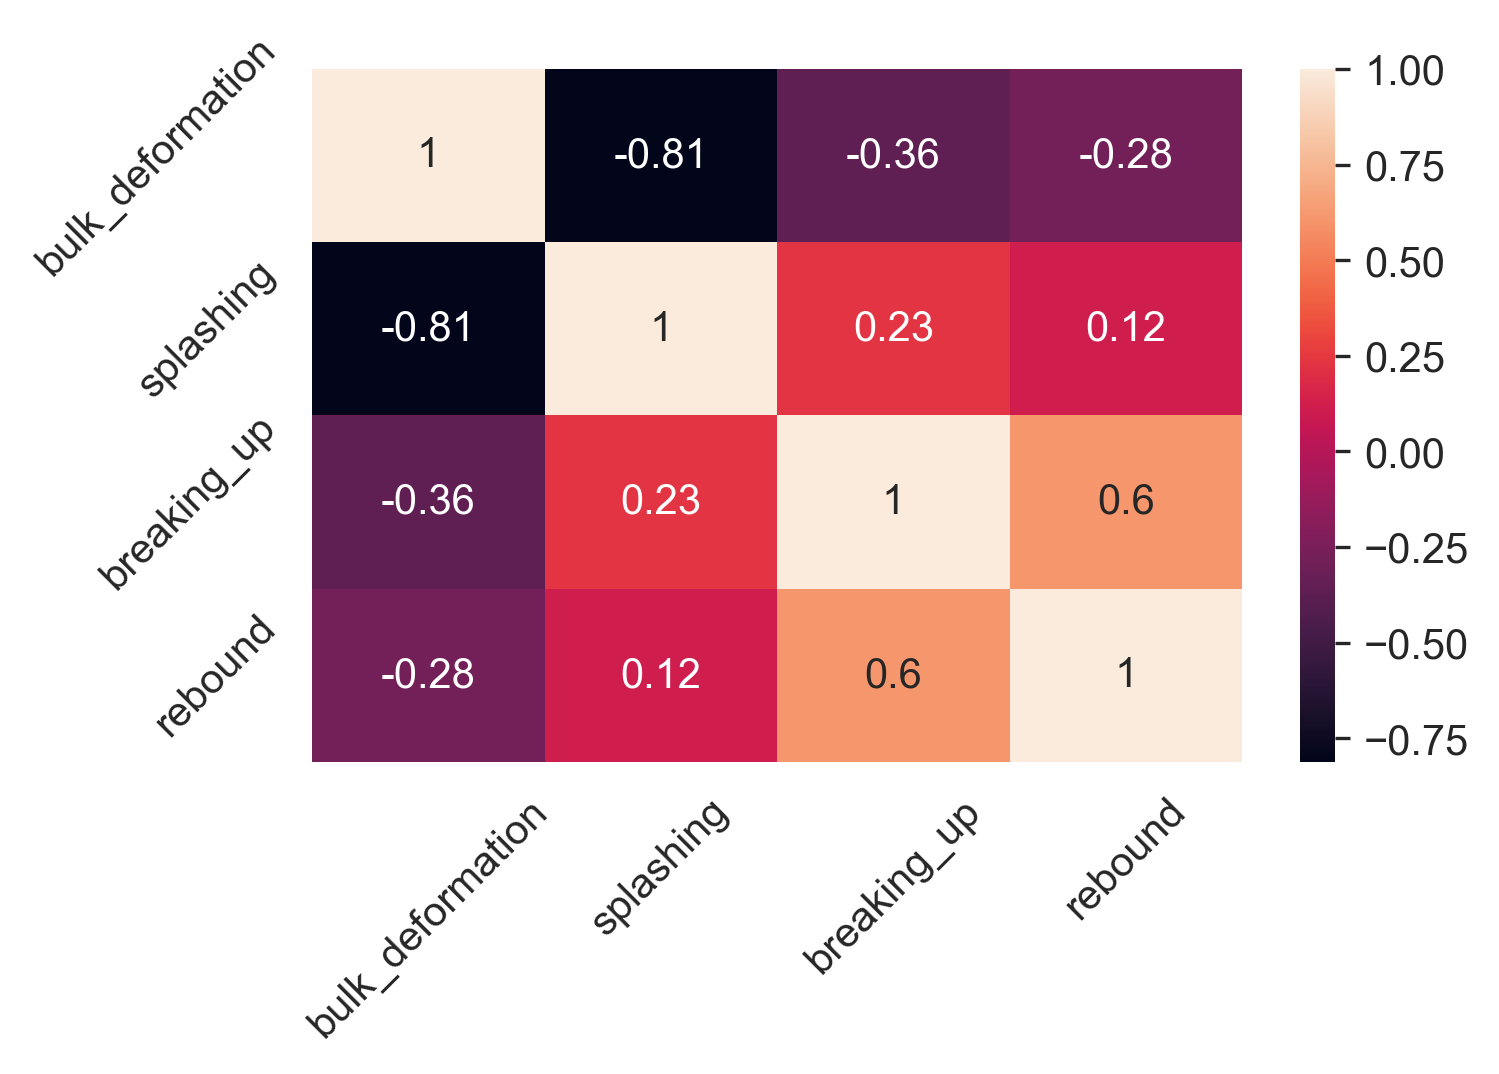

In [11]:
fig, ax = plt.subplots(1,1, figsize=(5,3))

sns.heatmap(
    df_main[targets + ['breaking_up', 'rebound']].corr(method='spearman'),
    annot=True,
    ax=ax
)

ax.set_yticklabels(ax.get_yticklabels(), rotation = 45);
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45);

plt.savefig(
    Path(
        Path('..', 'results', 'experiments'), 
        f'target_corr_map.pdf',
    ),
    bbox_inches='tight',
    dpi=600
)

## Prepare datasets for modelling

In [12]:
features_to_drop = (
    [
        'test', # not informative
        'height', # velocity is more informative
        'particle_diameter_cat', # necessary only for bar visualization
        'volume_fraction', # 0.04 and 0.05 are the same group of low volume fraction, as well as 0.08 and 0.10
        'particle_volume_fraction'
    ] 
    + impact_labels
    + generation_features
)

df_modelling = df_main.drop(features_to_drop, axis=1)
df_modelling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   bulk_deformation                 372 non-null    int64  
 1   splashing                        372 non-null    int64  
 2   wettability                      372 non-null    int64  
 3   roughness                        372 non-null    float64
 4   liquid_density                   372 non-null    int64  
 5   surface_tension                  372 non-null    float64
 6   viscosity                        372 non-null    float64
 7   particle_mean_diameter           372 non-null    float64
 8   particle_density                 372 non-null    int64  
 9   droplet_diameter                 372 non-null    float64
 10  inclination                      372 non-null    int64  
 11  roughness_binary                 372 non-null    int64  
 12  particle_liquid_densit

### Save full dataset

In [13]:
# df_modelling.to_excel('../data/df_modelling_full.xlsx', index=False)

### Feature selection

Put targets at the end

In [13]:
df_modelling = pd.concat(
    [
        df_modelling.iloc[:,2:],
        df_modelling.iloc[:,:2]
    ],
    axis=1
)

We_Re range:

In [14]:
df_main[['Re', 'We', 'K']].describe()

,Re,We,K
count,372.000000,372.000000,372.000000
mean,3289.703271,776.323767,171.483225
std,4733.083828,421.571957,81.819240
min,256.976895,142.008866,52.684981
25%,602.985155,641.130218,133.397611
50%,677.852440,810.236493,152.920577
75%,5765.682622,906.205711,236.153834
max,19139.168057,2184.164818,472.780129


Particle properties range:

In [15]:
df_main[['particle_droplet_diameter_ratio', 'particle_liquid_density_ratio']].describe()

,particle_droplet_diameter_ratio,particle_liquid_density_ratio
count,372.000000,372.000000
mean,0.026760,0.994035
std,0.025510,0.261595
min,0.011339,0.381356
25%,0.012604,0.943396
50%,0.013540,1.000000
75%,0.024635,1.016949
max,0.103774,1.864407


Let us consider correlation heatmap

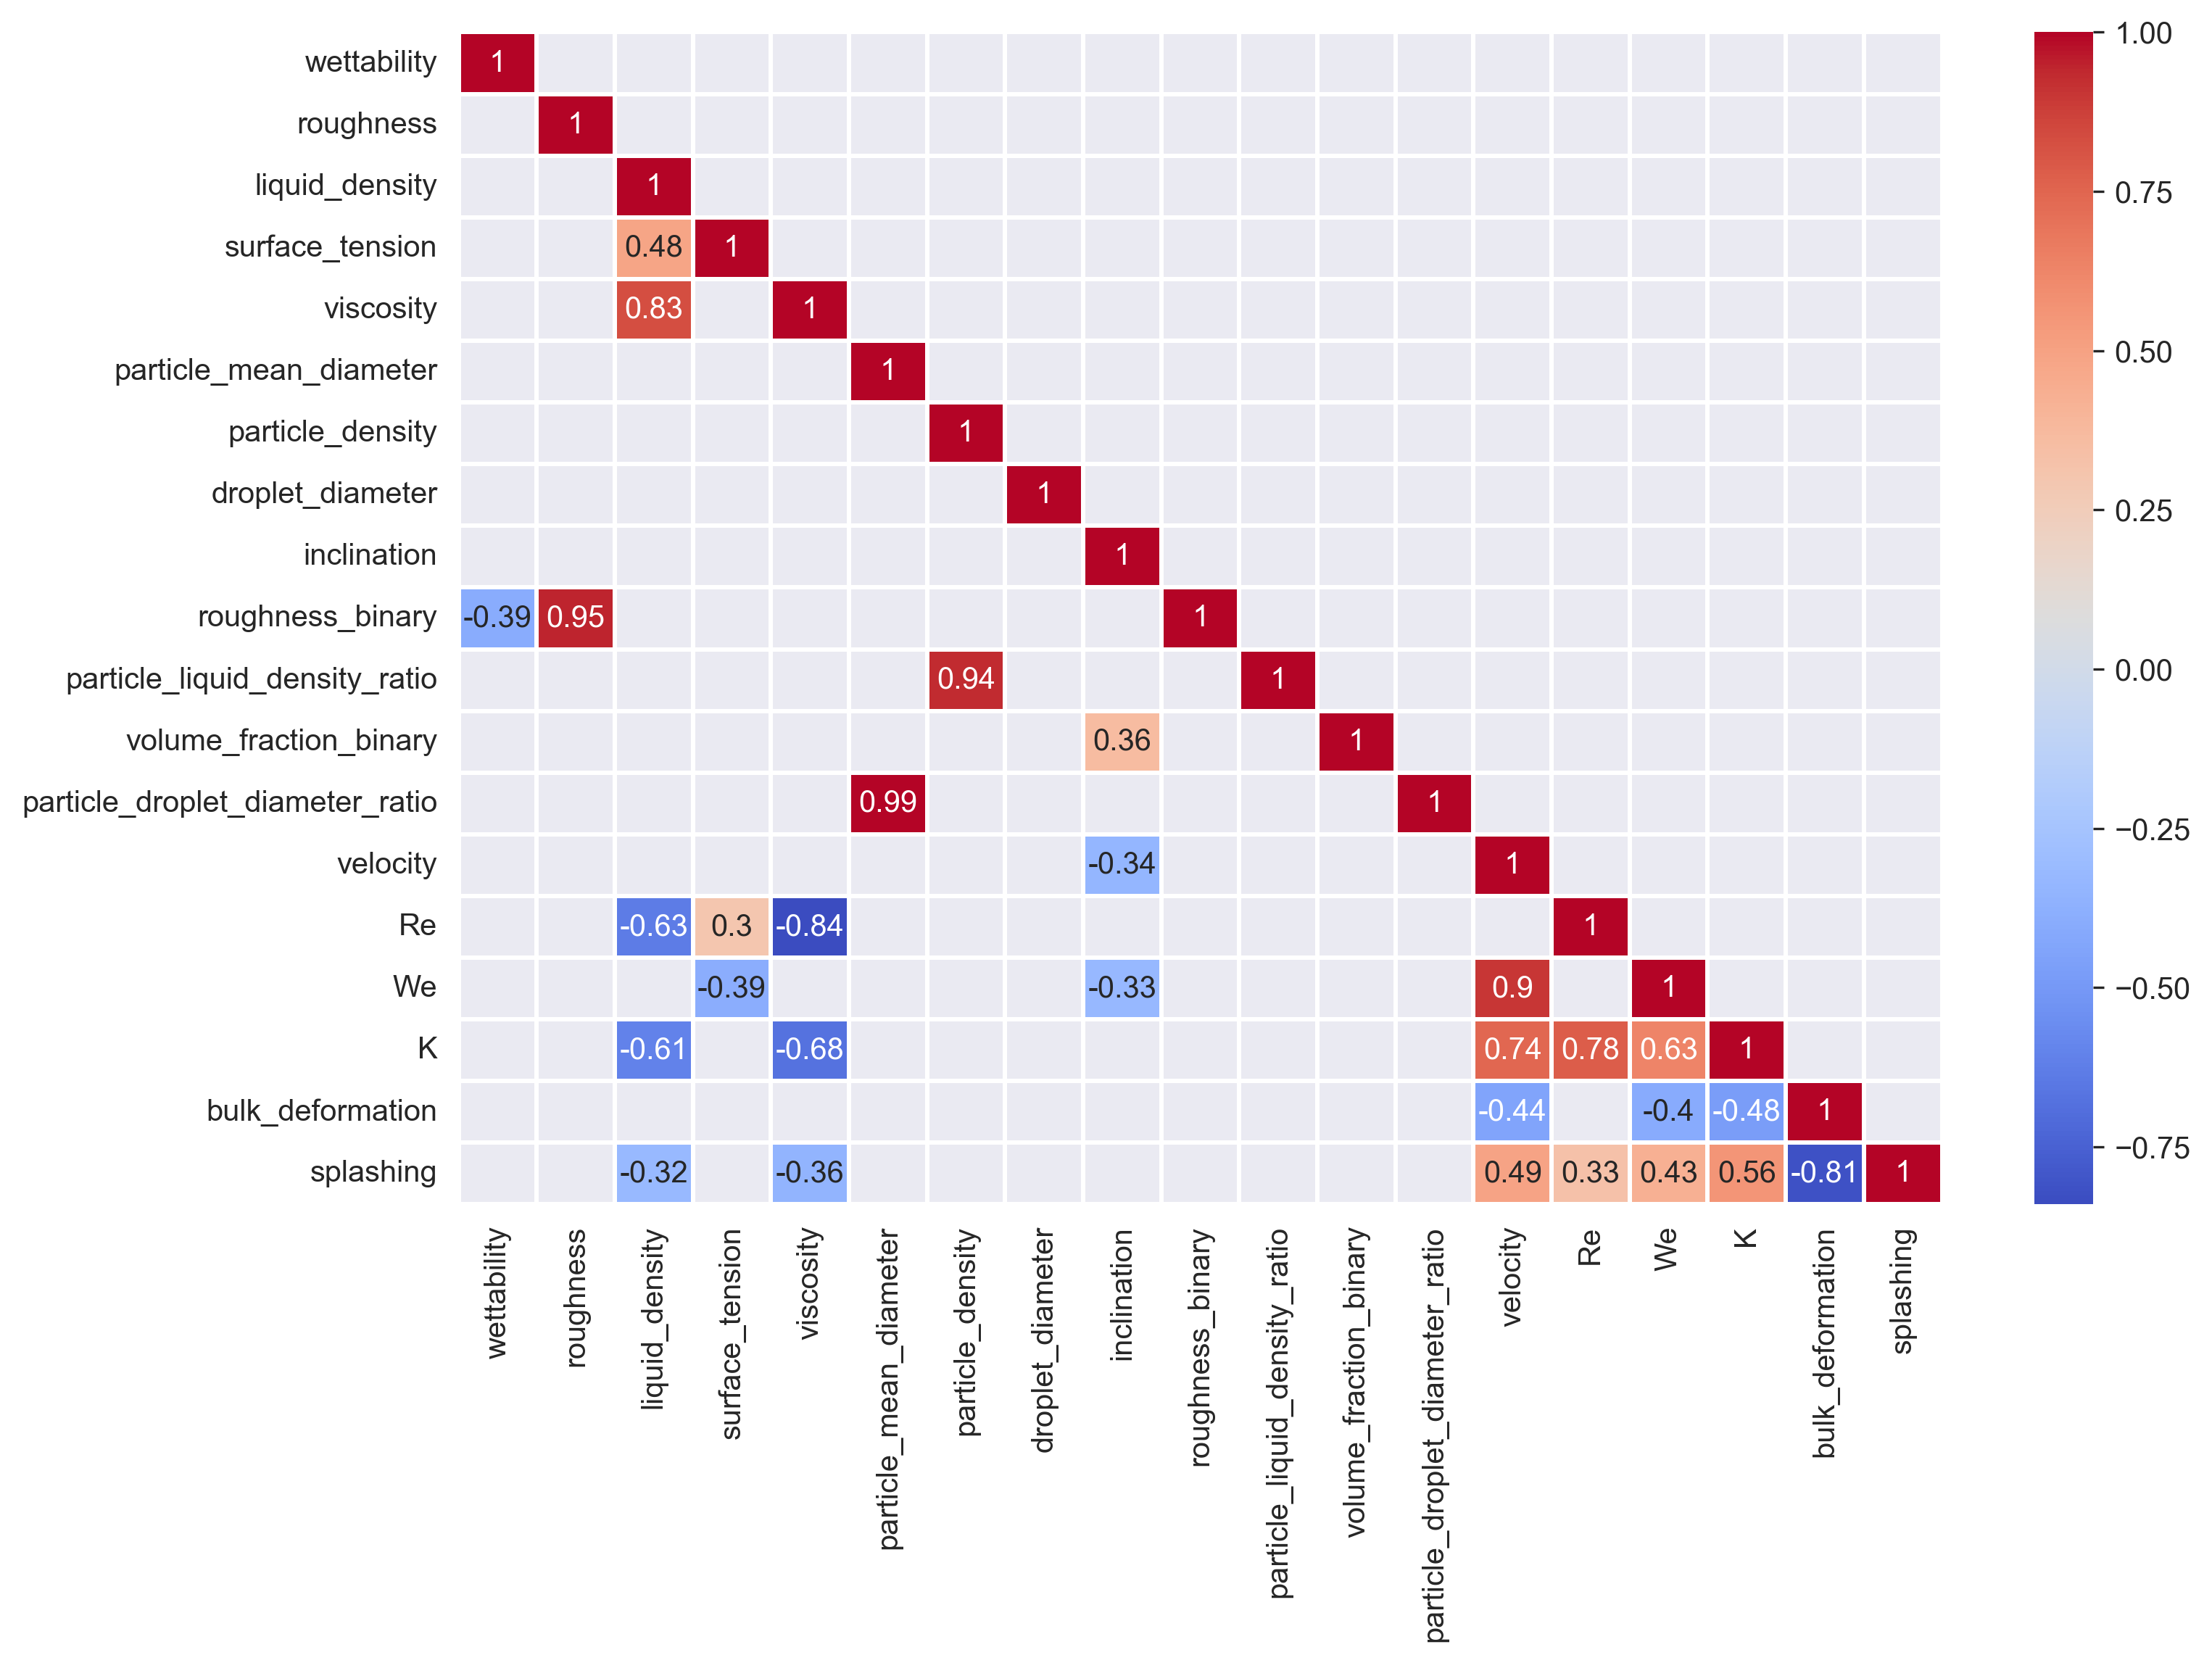

In [16]:
def get_corrmap(df, thresh = 0.3, ax=None, triag=False, figsize=(12, 12)):
    corr = df.corr()
    if ax==None:
        fig, ax = plt.subplots(figsize=figsize)
    if triag:
        inds = np.triu_indices(len(corr), k=1)
        mask = np.zeros(
            corr.shape,
            dtype=bool
        )
        mask[inds] = True
        corr[mask] = np.nan
    if thresh:
        corr = corr[np.abs(corr)>thresh]
    sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax, linewidths=1)
    ax.grid(False)

fig, ax = plt.subplots(figsize=(11, 7))

get_corrmap(df_modelling, triag=True, ax=ax)
plt.savefig(
    Path(
        Path('..', 'results', 'experiments'), 
        f'features_corr_map.pdf',
    ),
    bbox_inches='tight',
    dpi=600
)
# ax.set_xticklabels(ax.get_xticklabels(), rotation = 45);

Candidates to drop:
- **'particle_mean_diameter' or 'particle_droplet_diameter_ratio'**: 0.99
- **'particle_density' or 'particle_liquid_density_ratio'**: 0.94. Better to drop 'particle_density'
- **'roughness' or 'roughness_binary'**: 0.95. Better to drop roughness
- **'velocity' or 'We'**: 0.9. Better to drop 'velocity', since implicitly it is on the We and Re

Also:
- 'viscosity' or 'liquid_density': 0.83, since they are same for the same liquid. *Better to drop "liquid_density", since models do not choose liquid density?*
- 'viscosity' or 'Re': -0.84.


Let us drop multicollinear features (abs value 0.9 and higher)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 15 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   wettability                      372 non-null    int64  
 1   liquid_density                   372 non-null    int64  
 2   surface_tension                  372 non-null    float64
 3   viscosity                        372 non-null    float64
 4   droplet_diameter                 372 non-null    float64
 5   inclination                      372 non-null    int64  
 6   roughness_binary                 372 non-null    int64  
 7   particle_liquid_density_ratio    372 non-null    float64
 8   volume_fraction_binary           372 non-null    int64  
 9   particle_droplet_diameter_ratio  372 non-null    float64
 10  Re                               372 non-null    float64
 11  We                               372 non-null    float64
 12  K                     

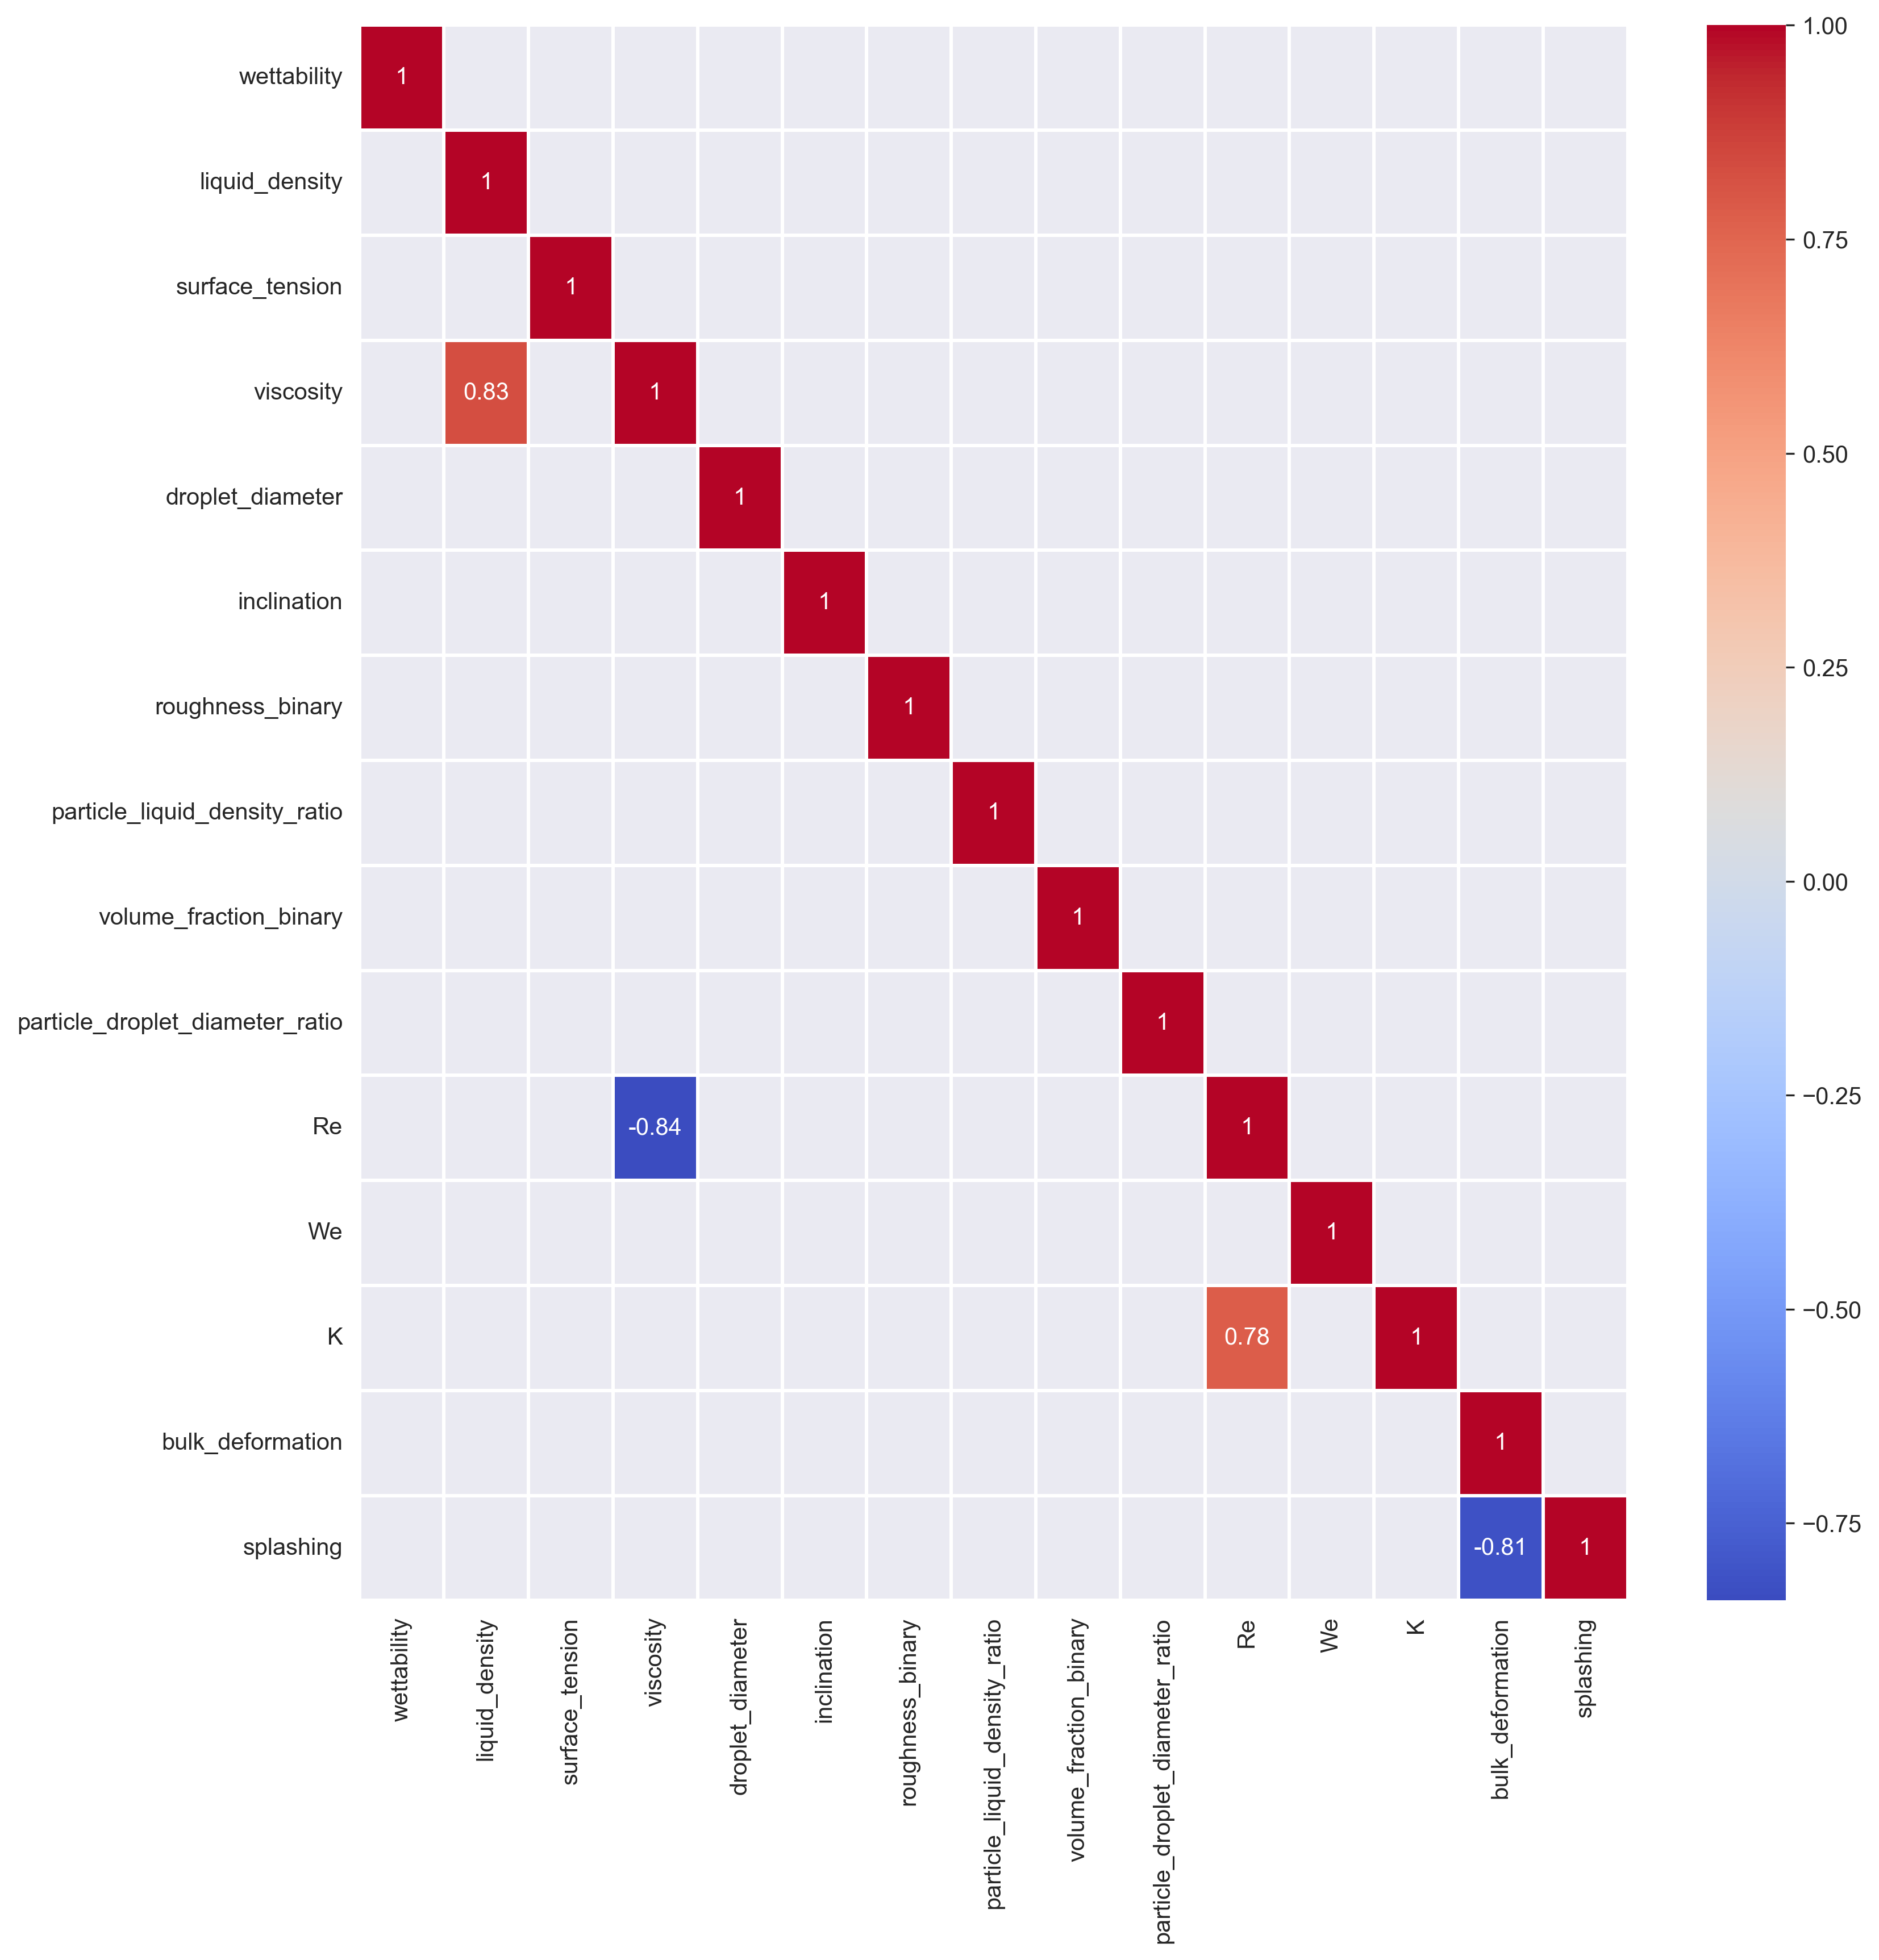

In [17]:
most_corr_features_to_drop = [
    'particle_mean_diameter',
    'particle_density', # particle_liquid_density_ratio is choosen
    'roughness', # roughness_binary is better to categorize glass roughness
    'velocity', # implicitly it is on the We and Re
    # 'viscosity' # has high correlation with liquid_density and 'Re'
] 

df_modelling_no_corr = df_modelling.drop(most_corr_features_to_drop, axis=1)
df_modelling_no_corr.info()
get_corrmap(df_modelling_no_corr, thresh=0.75, triag=True)

Droplet diameter:

<Axes: ylabel='Frequency'>

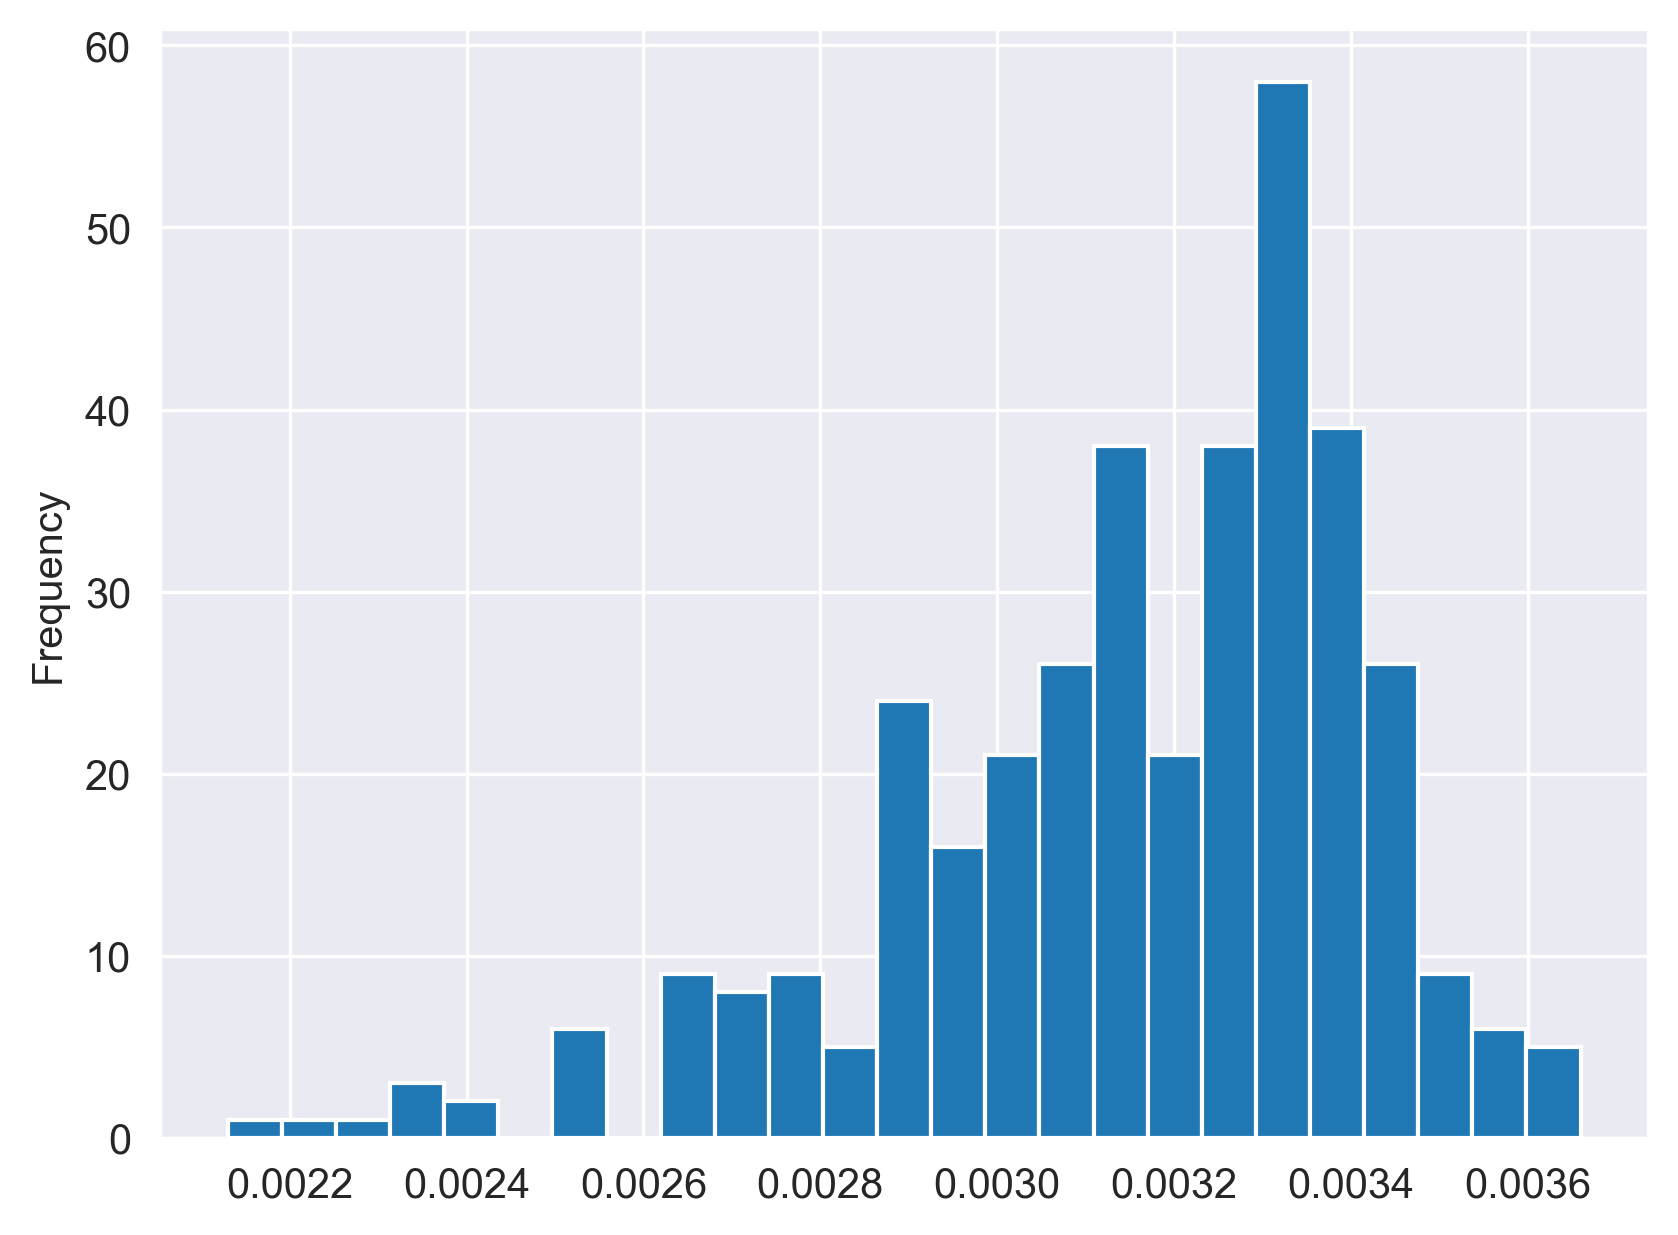

In [18]:
df_main['droplet_diameter'].plot.hist(bins=25)

### Save dataset without multicorrelation

In [12]:
# df_modelling_no_corr.to_excel('../data/df_modelling_no_multicollinearity.xlsx', index=False)

### Dimensionless modelling

Used to get generalized model

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   wettability                      372 non-null    int64  
 1   inclination                      372 non-null    int64  
 2   roughness_binary                 372 non-null    int64  
 3   particle_liquid_density_ratio    372 non-null    float64
 4   volume_fraction_binary           372 non-null    int64  
 5   particle_droplet_diameter_ratio  372 non-null    float64
 6   Re                               372 non-null    float64
 7   We                               372 non-null    float64
 8   K                                372 non-null    float64
 9   bulk_deformation                 372 non-null    int64  
 10  splashing                        372 non-null    int64  
dtypes: float64(5), int64(6)
memory usage: 32.1 KB


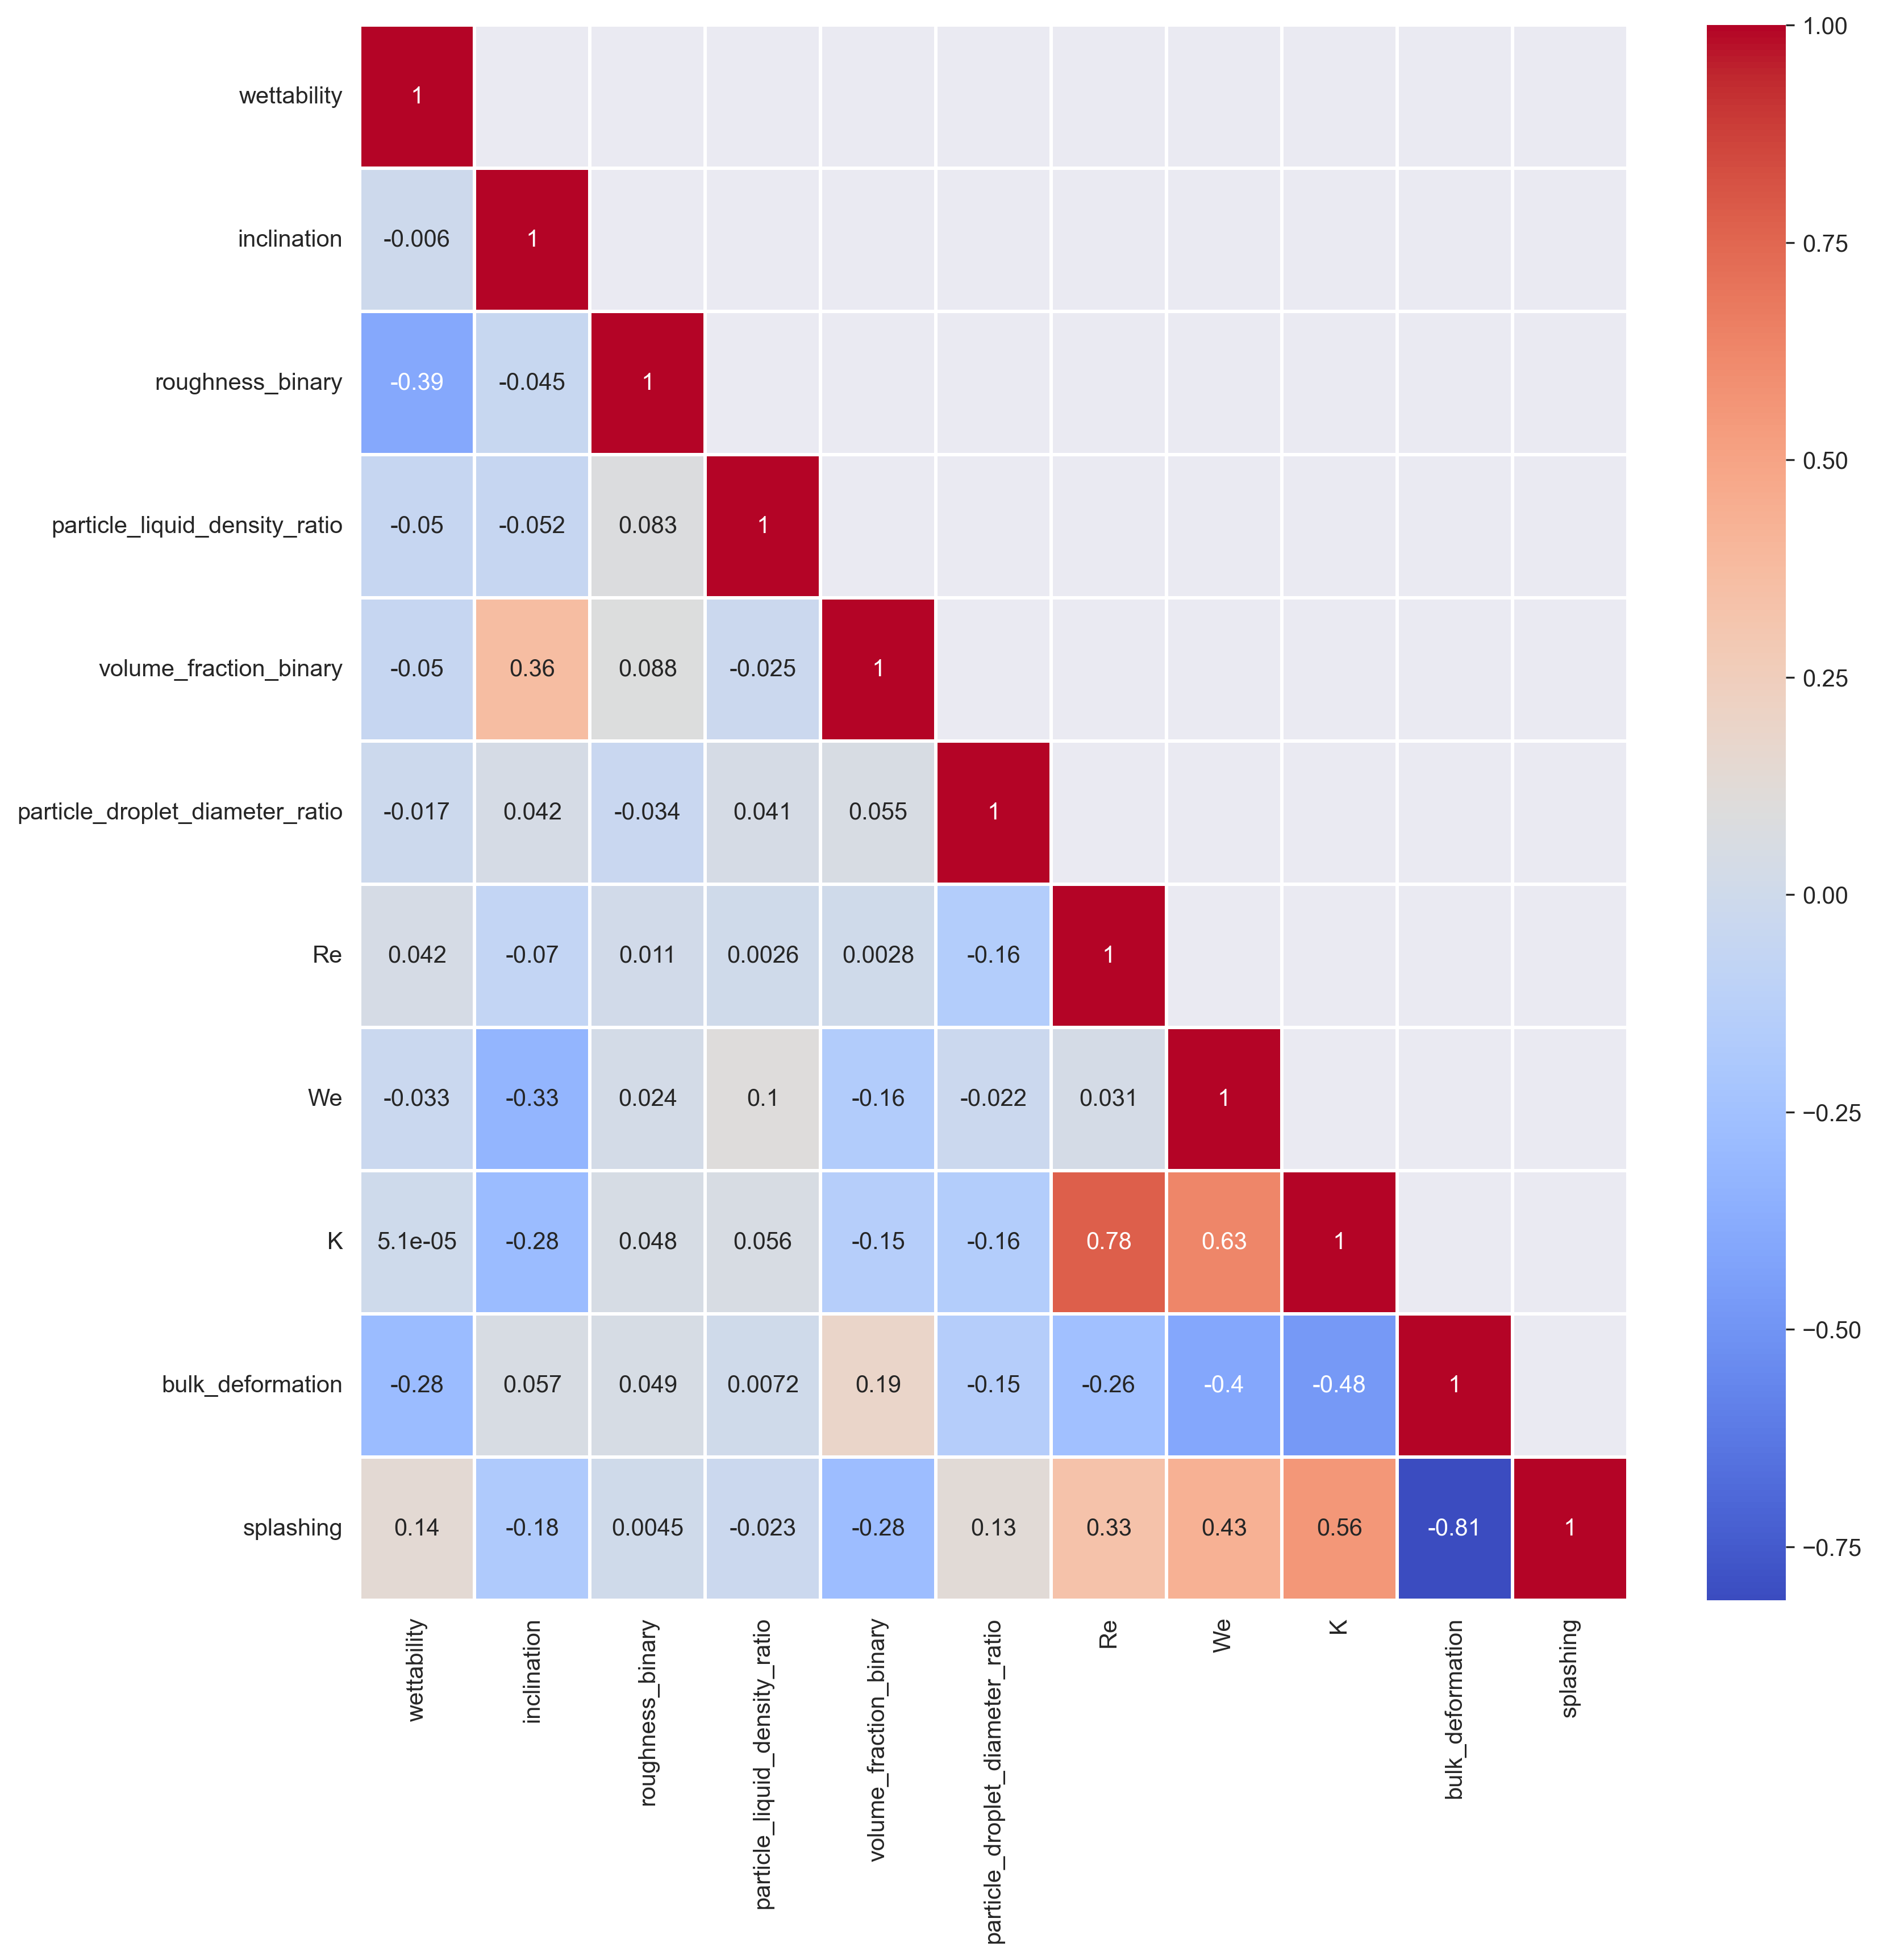

In [19]:
dimension_features = [
    'liquid_density',
    'surface_tension',
    'viscosity',
    'droplet_diameter'
]

df_modelling_dimensionless = df_modelling_no_corr.drop(
    dimension_features, 
    axis=1
)
df_modelling_dimensionless.info()
get_corrmap(df_modelling_dimensionless, thresh=0.0, triag=True)

### Save dataset for generalized modelling



In [14]:
# df_modelling_dimensionless.to_excel(
#     '../data/df_modelling_dimensionless.xlsx', 
#     index=False,
# )